# Аудит и сравнение: basic_dataset vs final_dataset

Сравниваем:
- `data/generated/basic_dataset` — исходный датасет (только train)
- `data/final_dataset` — финальный датасет со всеми источниками

In [1]:
from pathlib import Path
from collections import Counter
from math import ceil
import random

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from PIL import Image

repo_root = Path.cwd()
if not (repo_root / 'data').exists():
    repo_root = repo_root.parent.parent
assert (repo_root / 'data').exists(), 'Запускать из корня репозитория ML_comp'

BASIC_IMG_DIR  = repo_root / 'data' / 'generated' / 'basic_dataset' / 'images' / 'train'
BASIC_LBL_DIR  = repo_root / 'data' / 'generated' / 'basic_dataset' / 'labels' / 'train'
FINAL_IMG_DIR  = repo_root / 'data' / 'final_dataset' / 'images'
FINAL_LBL_DIR  = repo_root / 'data' / 'final_dataset' / 'labels'

CLASS_NAMES = [
    'HM', 'LQS', 'QHS', 'MS',
    'A1_SU-35', 'A2_C-130', 'A3_C-17', 'A4_C-5', 'A5_F-16', 'A6_TU-160',
    'A7_E-3', 'A8_B-52', 'A9_P-3C', 'A10_B-1B', 'A11_E-8', 'A12_TU-22',
    'A13_F-15', 'A14_KC-135', 'A15_F-22', 'A16_FA-18', 'A17_TU-95',
    'A18_KC-10', 'A19_SU-34', 'A20_SU-24', 'FSC',
]
NC = len(CLASS_NAMES)
print('Пути найдены:', BASIC_IMG_DIR.exists(), FINAL_IMG_DIR.exists())

Пути найдены: True True


## 1. Количество изображений и объектов

In [2]:
def analyze_dataset(img_dir: Path, lbl_dir: Path):
    class_counts = Counter()
    n_images = 0
    for f in lbl_dir.iterdir():
        if f.suffix != '.txt' or 'Zone' in f.name:
            continue
        n_images += 1
        for line in f.read_text().splitlines():
            parts = line.split()
            if parts:
                class_counts[int(parts[0])] += 1
    return n_images, sum(class_counts.values()), class_counts

b_imgs, b_inst, b_cls = analyze_dataset(BASIC_IMG_DIR, BASIC_LBL_DIR)
f_imgs, f_inst, f_cls = analyze_dataset(FINAL_IMG_DIR, FINAL_LBL_DIR)

summary = pd.DataFrame({
    'basic_dataset': [b_imgs, b_inst, round(b_inst / b_imgs, 1)],
    'final_dataset':  [f_imgs, f_inst, round(f_inst / f_imgs, 1)],
}, index=['Изображений', 'Объектов всего', 'Объектов / изображение'])
summary['Δ'] = summary['final_dataset'] - summary['basic_dataset']
summary['Δ%'] = (summary['Δ'] / summary['basic_dataset'] * 100).round(1).astype(str) + '%'
display(summary)

,basic_dataset,final_dataset,Δ,Δ%
Изображений,4480.0,9666.0,5186.0,115.8%
Объектов всего,20791.0,47999.0,27208.0,130.9%
Объектов / изображение,4.6,5.0,0.4,8.7%


## 2. Распределение по классам

In [3]:
rows = []
for i, name in enumerate(CLASS_NAMES):
    b = b_cls.get(i, 0)
    f = f_cls.get(i, 0)
    rows.append({'class_id': i, 'class_name': name,
                 'basic_dataset': b, 'final_dataset': f,
                 'delta': f - b,
                 'delta_pct': round((f - b) / b * 100, 1) if b > 0 else float('nan')})

df_cls = pd.DataFrame(rows).set_index('class_id')
display(df_cls.style
        .background_gradient(subset=['basic_dataset', 'final_dataset'], cmap='Blues')
        .format({'delta_pct': '{:+.1f}%'}))

,class_name,basic_dataset,final_dataset,delta,delta_pct
class_id,,,,,
0,HM,16,356,340,+2125.0%
1,LQS,28,465,437,+1560.7%
2,QHS,609,1911,1302,+213.8%
3,MS,1889,4811,2922,+154.7%
4,A1_SU-35,1317,2959,1642,+124.7%
5,A2_C-130,1297,3023,1726,+133.1%
6,A3_C-17,998,2162,1164,+116.6%
7,A4_C-5,500,1142,642,+128.4%
8,A5_F-16,1017,2279,1262,+124.1%


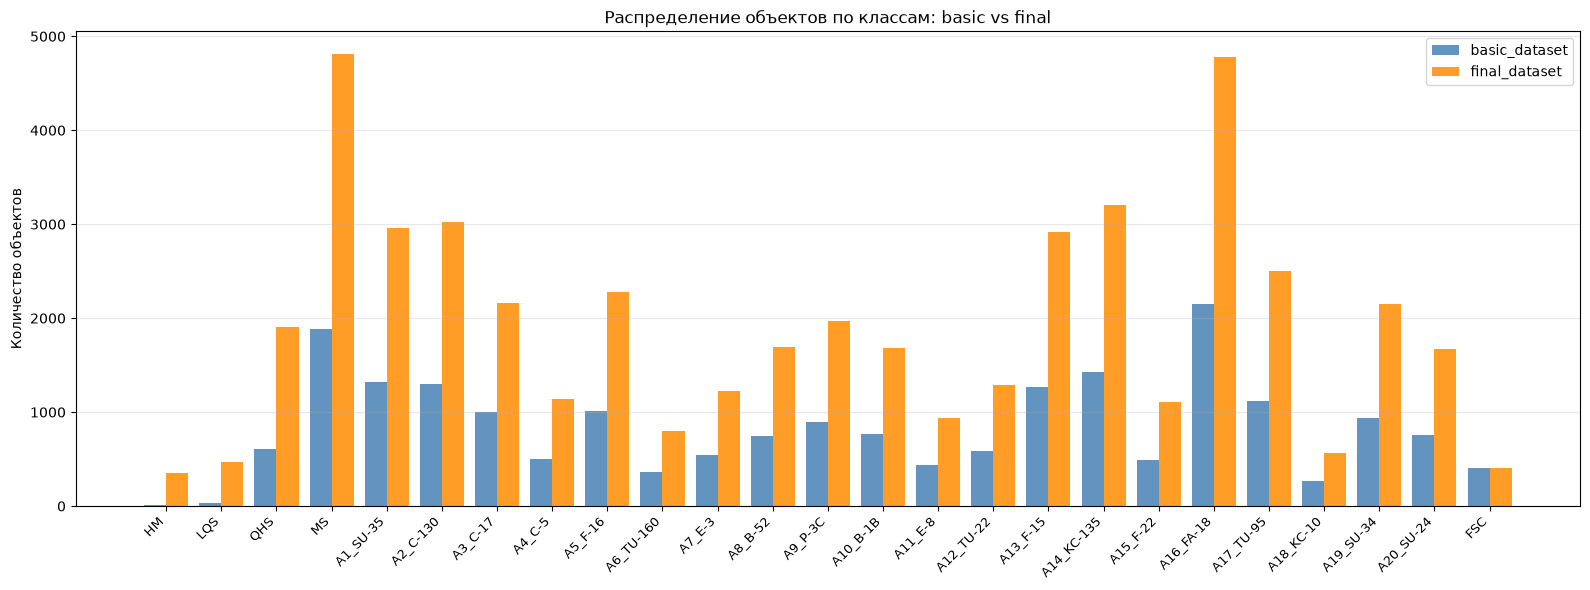

In [4]:
x = np.arange(NC)
width = 0.4

fig, ax = plt.subplots(figsize=(16, 6))
bars_b = ax.bar(x - width/2, df_cls['basic_dataset'], width, label='basic_dataset', color='steelblue', alpha=0.85)
bars_f = ax.bar(x + width/2, df_cls['final_dataset'], width, label='final_dataset',  color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Количество объектов')
ax.set_title('Распределение объектов по классам: basic vs final')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

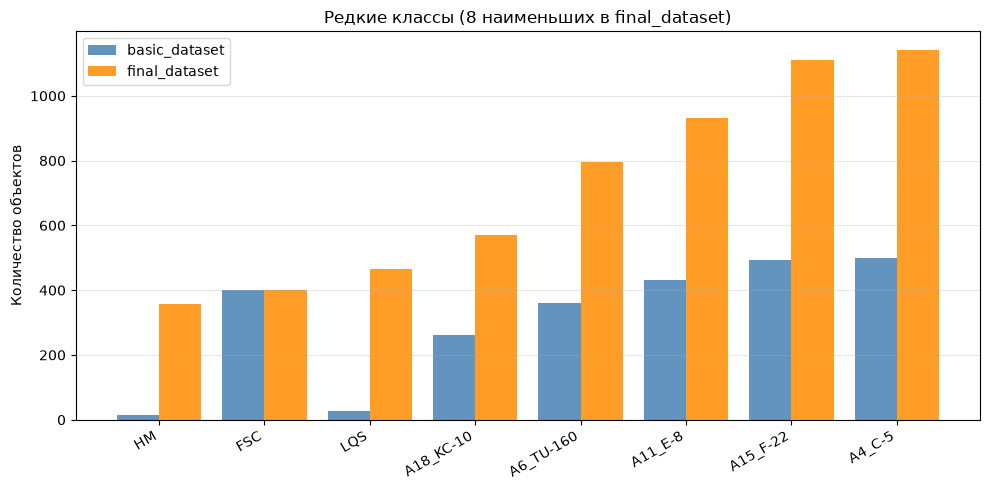

In [5]:
# Редкие классы крупно
rare_idx = df_cls.nsmallest(8, 'final_dataset').index.tolist()
df_rare = df_cls.loc[rare_idx]

x2 = np.arange(len(rare_idx))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x2 - width/2, df_rare['basic_dataset'], width, label='basic_dataset', color='steelblue', alpha=0.85)
ax.bar(x2 + width/2, df_rare['final_dataset'], width, label='final_dataset',  color='darkorange', alpha=0.85)
ax.set_xticks(x2)
ax.set_xticklabels(df_rare['class_name'], rotation=30, ha='right')
ax.set_ylabel('Количество объектов')
ax.set_title('Редкие классы (8 наименьших в final_dataset)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Источники изображений в final_dataset

Определяем источник по префиксу имени файла.

,source,images
0,ShipRSImageNet,5186
1,MAR20,3073
3,other,706
2,raw (original),701


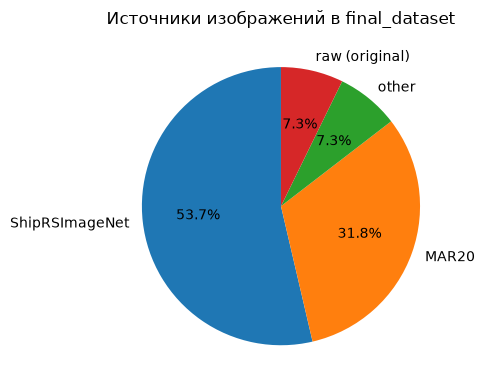

In [6]:
def detect_source(name: str) -> str:
    if name.startswith('01-PAN') or name.startswith('fsc_'):
        return 'raw (original)'
    if name.startswith('MAR20_'):
        return 'MAR20'
    if name.endswith('.rf.' + name.split('.rf.')[-1]) and '.rf.' in name:
        return 'ShipRSImageNet'
    if name[:6].isdigit() and '_bmp' in name:
        return 'ShipRSImageNet'
    if '_jpg.rf.' in name or '_bmp.rf.' in name:
        return 'ShipRSImageNet'
    return 'other'

source_counts = Counter()
for f in FINAL_IMG_DIR.iterdir():
    if f.suffix in ('.jpg', '.png', '.jpeg'):
        source_counts[detect_source(f.name)] += 1

df_src = pd.DataFrame(source_counts.items(), columns=['source', 'images']).sort_values('images', ascending=False)
display(df_src)

fig, ax = plt.subplots(figsize=(7, 4))
ax.pie(df_src['images'], labels=df_src['source'], autopct='%1.1f%%', startangle=90)
ax.set_title('Источники изображений в final_dataset')
plt.tight_layout()
plt.show()

## 4. Визуализация bounding boxes из final_dataset

Загружаем случайные изображения и рисуем аннотации.

In [7]:
COLORS = plt.colormaps['tab20'].resampled(NC)

def read_yolo(label_path: Path):
    boxes = []
    for ln, line in enumerate(label_path.read_text().splitlines(), 1):
        parts = line.split()
        if len(parts) == 5:
            cls, cx, cy, w, h = int(parts[0]), *map(float, parts[1:])
            boxes.append((ln, cls, cx, cy, w, h))
    return boxes

def draw_boxes(img_path: Path, lbl_path: Path, ax=None, title=None):
    img = Image.open(img_path).convert('RGB')
    W, H = img.size
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)
    for ln, cls, cx, cy, bw, bh in read_yolo(lbl_path):
        x1 = (cx - bw / 2) * W
        y1 = (cy - bh / 2) * H
        color = COLORS(cls)
        ax.add_patch(Rectangle((x1, y1), bw * W, bh * H,
                                fill=False, edgecolor=color, linewidth=2))
        ax.text(max(0, x1), max(0, y1), CLASS_NAMES[cls],
                color='white', fontsize=7, va='top',
                bbox=dict(facecolor=color, alpha=0.8, pad=2, edgecolor='none'))
    ax.set_title(title or img_path.stem, fontsize=8)
    ax.axis('off')
    return ax

print('Хелперы загружены.')

Хелперы загружены.


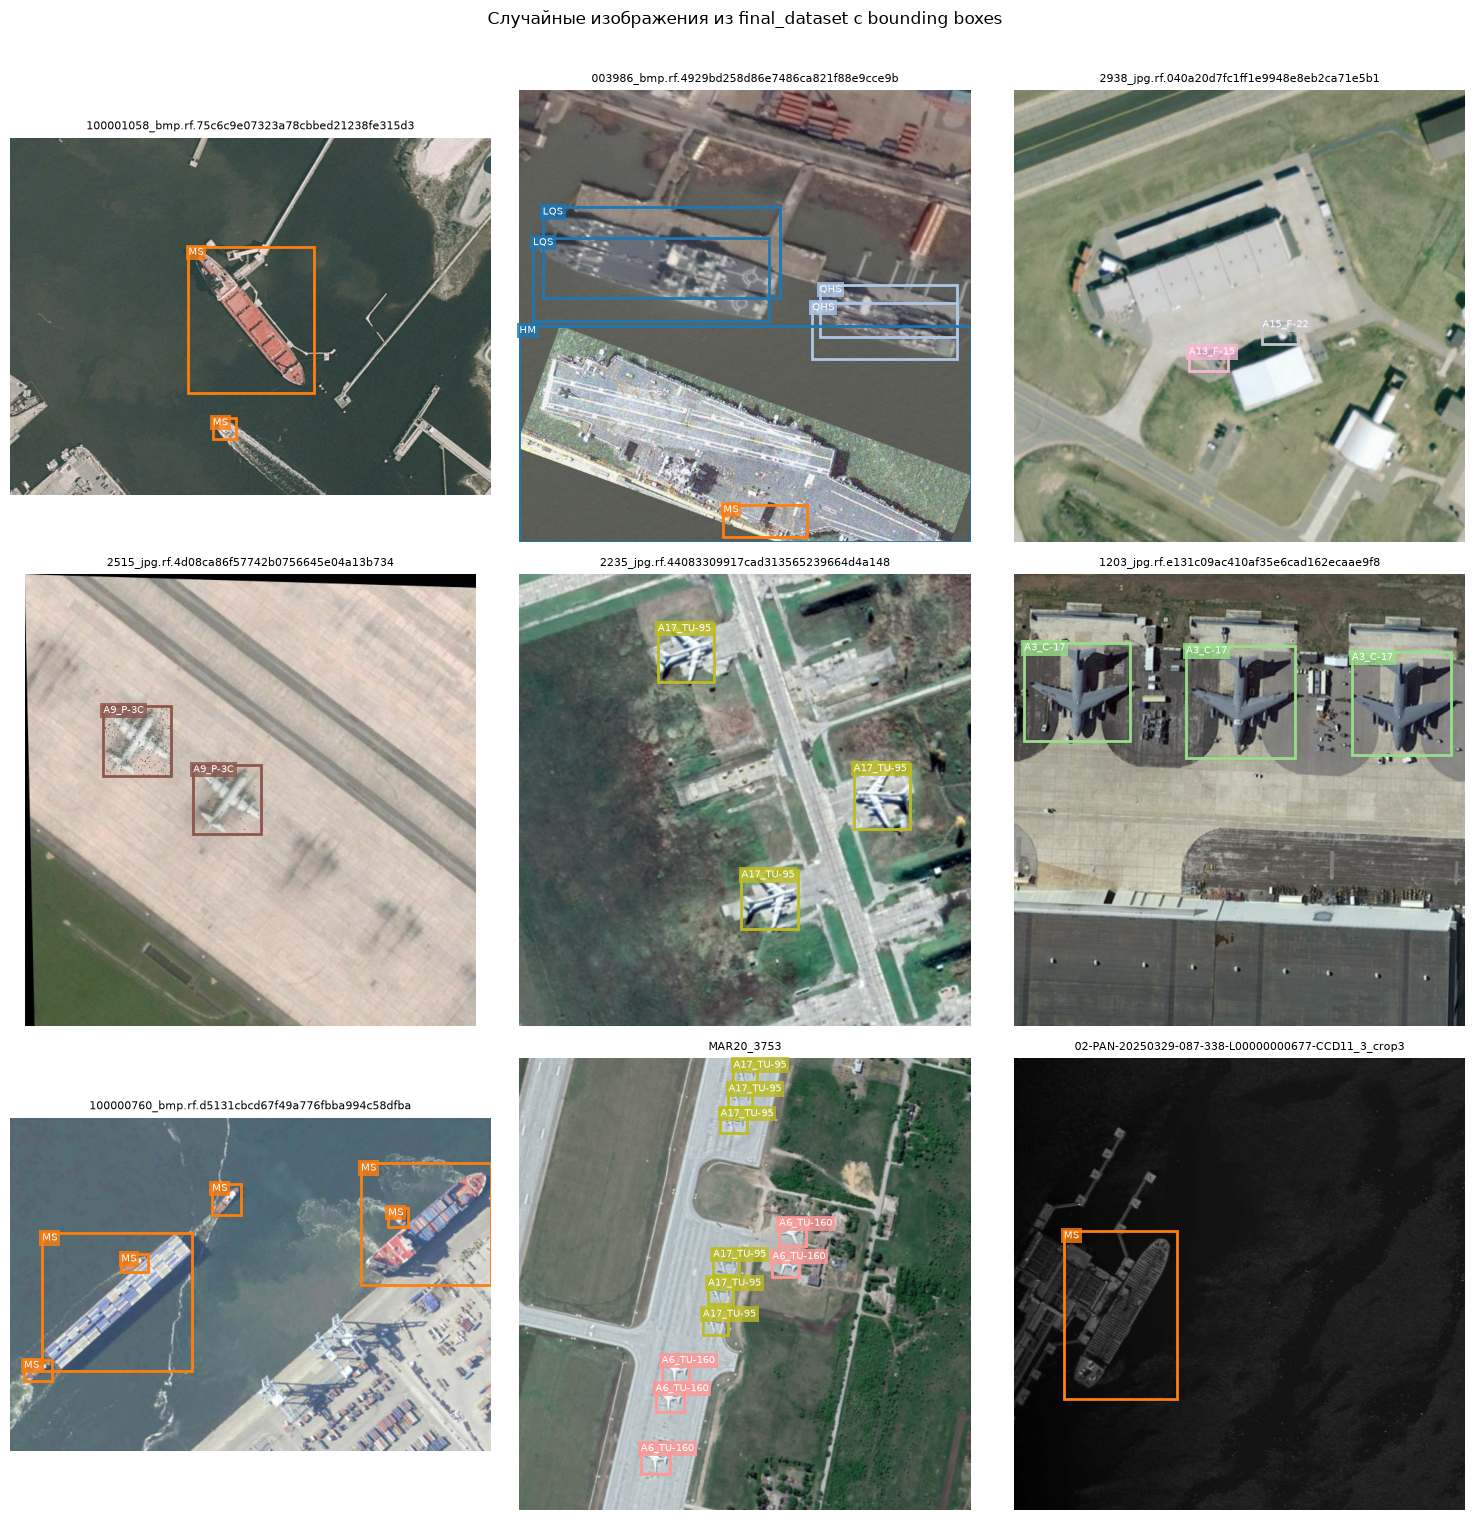

In [8]:
# Случайные N изображений из final_dataset
N_SHOW = 9
COLS   = 3
SEED   = 42

all_imgs = sorted(FINAL_IMG_DIR.glob('*.jpg')) + sorted(FINAL_IMG_DIR.glob('*.png'))
rng = random.Random(SEED)
sample = rng.sample(all_imgs, min(N_SHOW, len(all_imgs)))

rows = ceil(len(sample) / COLS)
fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 5, rows * 5))
axes = list(np.array(axes).flat)

for ax, img_path in zip(axes, sample):
    lbl_path = FINAL_LBL_DIR / (img_path.stem + '.txt')
    if lbl_path.exists():
        draw_boxes(img_path, lbl_path, ax=ax)
    else:
        ax.set_title(f'{img_path.stem}\n(нет лейбла)', fontsize=7)
        ax.axis('off')

for ax in axes[len(sample):]:
    ax.axis('off')

plt.suptitle('Случайные изображения из final_dataset с bounding boxes', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

Изображений с классом "HM": 339, показываем 6


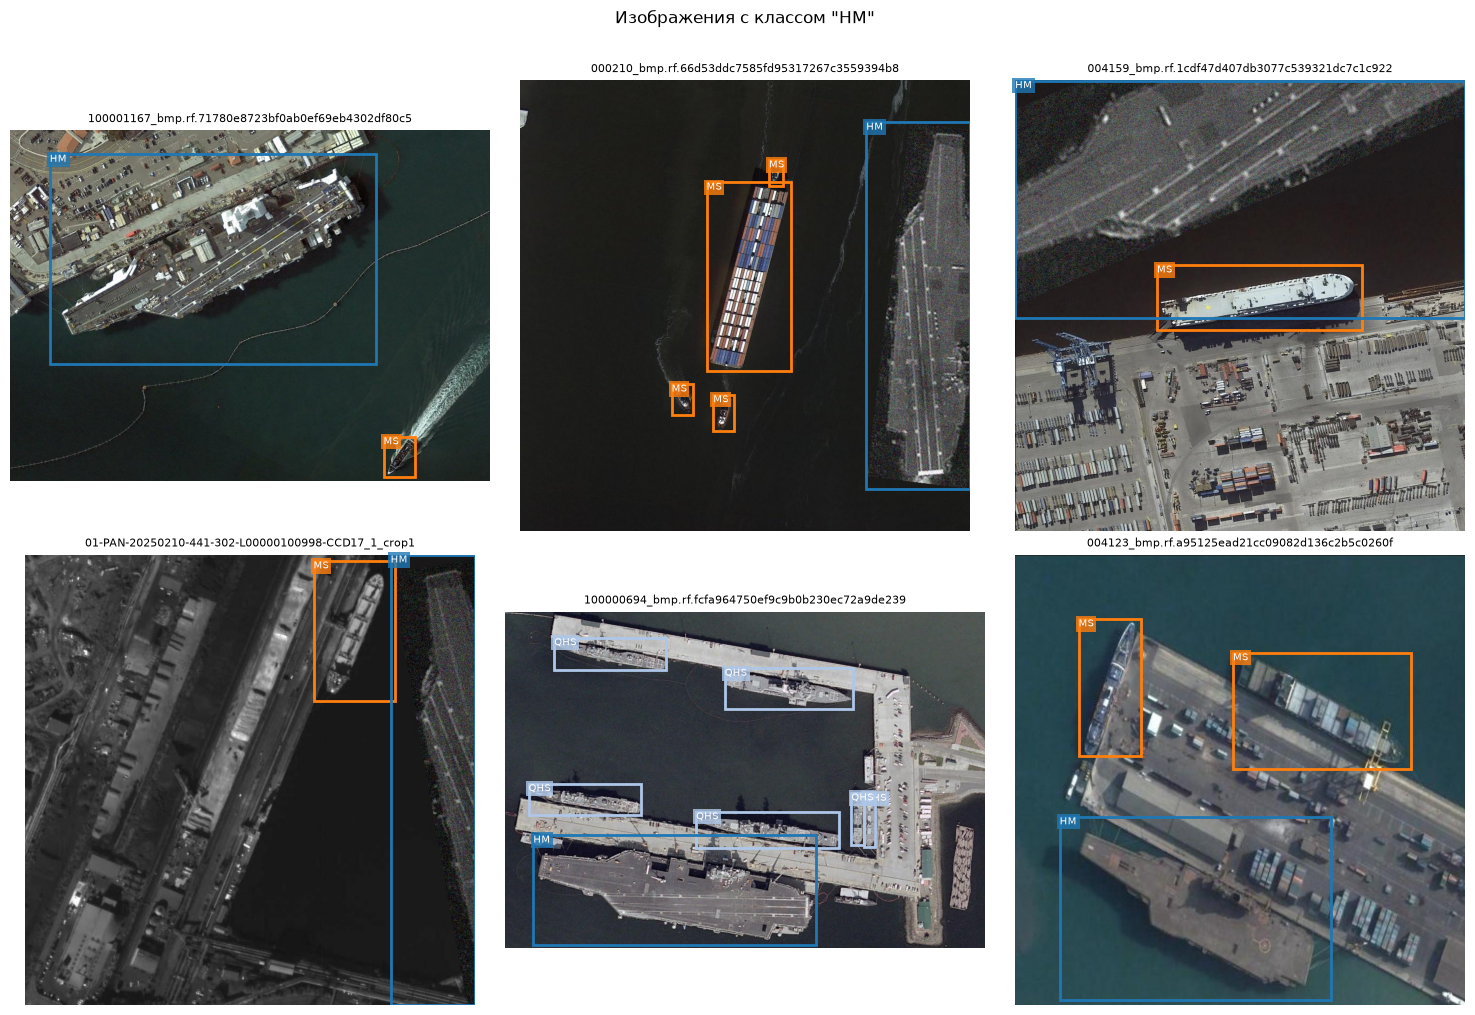

In [9]:
# Показать изображения с конкретным классом
TARGET_CLASS = 'HM'   # <-- меняй здесь
N_SHOW2 = 6
COLS2   = 3

target_id = CLASS_NAMES.index(TARGET_CLASS)
candidates = []
for lbl_path in FINAL_LBL_DIR.iterdir():
    if lbl_path.suffix != '.txt':
        continue
    classes_in = {int(l.split()[0]) for l in lbl_path.read_text().splitlines() if l.strip()}
    if target_id in classes_in:
        img_path = FINAL_IMG_DIR / (lbl_path.stem + '.jpg')
        if not img_path.exists():
            img_path = FINAL_IMG_DIR / (lbl_path.stem + '.png')
        if img_path.exists():
            candidates.append((img_path, lbl_path))

rng2 = random.Random(0)
sample2 = rng2.sample(candidates, min(N_SHOW2, len(candidates)))
print(f'Изображений с классом "{TARGET_CLASS}": {len(candidates)}, показываем {len(sample2)}')

rows2 = ceil(len(sample2) / COLS2)
fig2, axes2 = plt.subplots(rows2, COLS2, figsize=(COLS2 * 5, rows2 * 5))
axes2 = list(np.array(axes2).flat)

for ax, (img_path, lbl_path) in zip(axes2, sample2):
    draw_boxes(img_path, lbl_path, ax=ax)

for ax in axes2[len(sample2):]:
    ax.axis('off')

plt.suptitle(f'Изображения с классом "{TARGET_CLASS}"', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

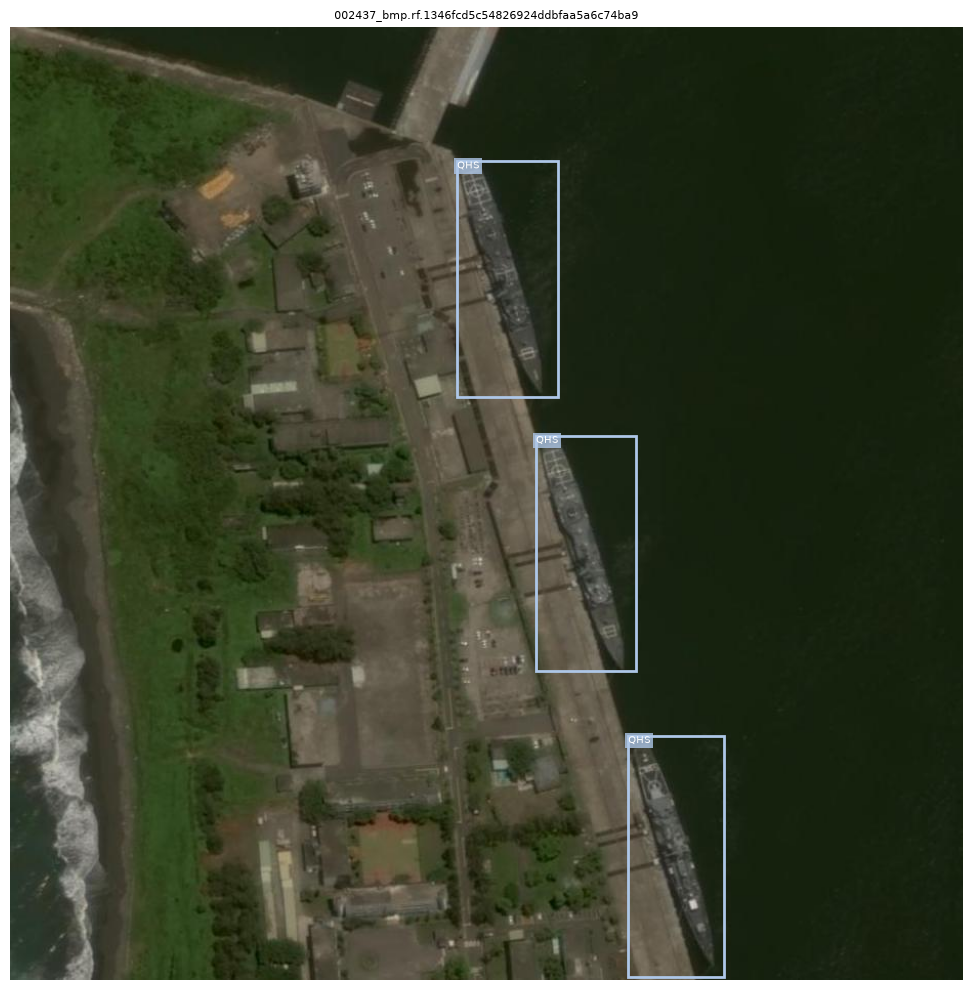

In [10]:
# Одно конкретное изображение по имени
IMAGE_NAME = None  # например: 'MAR20_100.jpg'  — или None для случайного

if IMAGE_NAME is None:
    img_path = random.choice(all_imgs)
else:
    img_path = FINAL_IMG_DIR / IMAGE_NAME

lbl_path = FINAL_LBL_DIR / (img_path.stem + '.txt')
fig, ax = plt.subplots(figsize=(10, 10))
draw_boxes(img_path, lbl_path, ax=ax)
plt.tight_layout()
plt.show()